In [1]:
# testing the new recomp functions

import numpy as np
from scipy.stats import uniform_direction
import sys, os
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_a_hist_at_sat_r_hist, compute_F_hist_at_sat_r_hist, F_vec_to_Fr, get_norm_across_last_dim, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array, get_toa_grid_from_rad_config
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms, get_Rotation

import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import get_faceted_sphere_mesh, QuadratureGrid, KnockeGridMONTE, RegularLatLonGrid
from SpaceBalls.plotter import Plotter
import SpaceBalls.constants as constants
import itertools
import time
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
LIGHT_SPEED = constants.light_speed()

def get_random_vectors(n):
    return uniform_direction.rvs(dim=3, size=n)


def get_avg_cross_sectional_area(normal_vecs, areas):

    all_areas = []
    all_s = -get_random_vectors(10000)

    for i, s in enumerate(all_s):
        total_A = 0
        for i, (n, area) in enumerate(zip(normal_vecs, areas)):
            cos = np.max([0, np.dot(-s, n)])
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
    
    return np.mean(all_areas)

desired_sb = {
    'force_settings': 2,
    'integration_settings': 110,  # 0 for GRACE-FO_orbit
    'orbit_name': 'Ajisai_orbit', # 'GRACE-FO_orbit', # 'LAGEOS_orbit', #'GRACE-FO_orbit',
    'delta_t_out': 15,
}

keys = input_manager.get_primary_keys(desired_sb)
#keys = [key for key in keys if 'LAGEOS' not in key]
assert(len(keys)==1)
sb_tag = keys[0]

sb_tag = 'SB_R800_21'  # 'GRACE-FO_spherical' # 'LAGEOS_119' # 'SB_R800_3'

#EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
EEI_truth = 'EEI_truth_35' # + str(EEI_truth)
grid = get_toa_grid_from_rad_config(radiation_settings_from_EEI_truth_name(EEI_truth))

n_days = 2
start_idx = 10
day_idxs = range(start_idx, start_idx+n_days)
all_jd = [None] * n_days
all_erp = [None] * n_days
all_erp_recomp_plated = [None] * n_days
all_erp_recomp_cannonball = [None] * n_days
all_srp = [None] * n_days
all_srp_recomp_plated = [None] * n_days
all_srp_recomp_cannonball = [None] * n_days

sb_og_dict = input_manager.get_dicts(sb_tag)
mass = sb_og_dict['sc_params']['mass']
area = sb_og_dict['sc_params']['area']
sat_radius = np.sqrt(area/np.pi)

def select_solar_panel_facets(mesh, fraction, distribution_mode):
    """Return a Boolean solar-panel mask aligned with mesh[5].simplices.

    mesh is the tuple returned by get_faceted_sphere_mesh. fraction must be
    in [0, 1] and specifies a fraction of facets, not surface area; the count
    is rounded to the nearest integer (half up). distribution_mode is
    "random" (uniform sampling without replacement) or "equatorial" (a belt
    around the z axis, selecting centroids closest to the z=0 plane).
    Equatorial ties follow facet order, so the final ring may be partial.
    The mesh is not modified. np.random.seed can make random selection repeatable.
    """
    if not np.isscalar(fraction) or not np.isfinite(fraction) or not 0 <= fraction <= 1:
        raise ValueError("fraction must be a finite number between 0 and 1")
    if distribution_mode not in ("random", "equatorial"):
        raise ValueError("distribution_mode must be 'random' or 'equatorial'")

    _, centroids, _, _, _, hull = mesh
    n_facets = len(hull.simplices)
    n_panels = int(np.floor(fraction * n_facets + 0.5))
    solar_panel_mask = np.zeros(n_facets, dtype=bool)
    if distribution_mode == "random":
        panel_indices = np.random.choice(n_facets, size=n_panels, replace=False)
    else:
        panel_indices = np.argsort(np.abs(centroids[:, 2]), kind="stable")[:n_panels]
    solar_panel_mask[panel_indices] = True
    return solar_panel_mask

def compute_a_plated_vs_cannonball(sat_dict, spin_f):

    avg_ca_SW = np.sum(sat_dict['plate_ca_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    avg_cd_SW = np.sum(sat_dict['plate_cd_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    avg_cs_SW = np.sum(sat_dict['plate_cs_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
    # true_avg_area = get_avg_cross_sectional_area(sat_dict['plate_normals'], sat_dict['plate_areas'])
    true_avg_area = np.sum(sat_dict['plate_areas']) / 4

    F_to_a = true_avg_area / sat_dict['mass'] * (avg_ca_SW + avg_cs_SW + 13*avg_cd_SW/9) / LIGHT_SPEED
    F_to_a_monte = 1/get_acc_to_flux_factor(sb_tag)

    # spin_f = 0.015 # [Hz]
    spin_w = 2 * np.pi * spin_f
    theta_0 = 0

    for i, day_idx in enumerate(day_idxs):

        r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
        u_hist_day = r_hist_day/get_norm_across_last_dim(r_hist_day)[...,None]
        jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
        all_jd[i] = jd_hist_day

        erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3
        all_erp[i] = erp_ar_hist

        srp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'srp.npy'))[:,0] * 1e3
        all_srp[i] = srp_ar_hist

        # rotation axis in the direction of the orbit angular momentum
        v_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'vxvyvz_ecef.npy'))
        h_hist_day = np.cross(r_hist_day, v_hist_day, axis=1)
        rot_axis_hist = h_hist_day / get_norm_across_last_dim(h_hist_day)[:,None]

        theta = theta_0 + spin_w * (jd_hist_day - jd_hist_day[0]) * (24*3600)
        sat_R_body2ECEF_hist = get_Rotation(rot_axis=rot_axis_hist.T, theta_hist=theta).as_matrix()

        erp_a_hist, srp_a_hist = compute_a_hist_at_sat_r_hist(EEI_truth, 
                                                            sat_dict,
                                                            r_hist_day, 
                                                            jd_hist_day, 
                                                            toa_grid=grid,
                                                            sat_R_body2ECEF_hist=sat_R_body2ECEF_hist)
        all_erp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(erp_a_hist, u_hist_day[None,...]))
        all_srp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(srp_a_hist, u_hist_day[None,...]))

        erp_F_hist, srp_F_hist = compute_F_hist_at_sat_r_hist(EEI_truth, #'EEI_truth_1', 
                                                        r_hist_day, 
                                                        jd_hist_day, 
                                                        toa_grid=grid,
                                                        erp_wl_split=False)
        all_erp_recomp_cannonball[i] = -F_to_a * np.squeeze(F_vec_to_Fr(erp_F_hist, u_hist_day[None,...]))
        all_srp_recomp_cannonball[i] = -F_to_a * np.squeeze(F_vec_to_Fr(srp_F_hist, u_hist_day[None,...]))

        theta_0 = theta[-1] + np.mean(np.diff(theta)) # add slight dt to the start of next day

    erp_cannonball = np.concatenate(all_erp_recomp_cannonball)
    srp_cannonball = np.concatenate(all_srp_recomp_cannonball)
    erp_plated = np.concatenate(all_erp_recomp_plated)
    srp_plated = np.concatenate(all_srp_recomp_plated)

    net_cannonball = erp_cannonball + srp_cannonball
    net_plated = erp_plated + srp_plated

    return net_cannonball, net_plated


r vectors projected to ellipsoid


SPIN FREQ.: 0.0 HZ
Number of faces: 24
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Number of faces: 48
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computi

/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/plotter.py:156: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(cls.fig_width*f_width, cls.fig_height*f_height), dpi=200)


SPIN FREQ.: 0.05 HZ
Number of faces: 24
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Number of faces: 48
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Comput

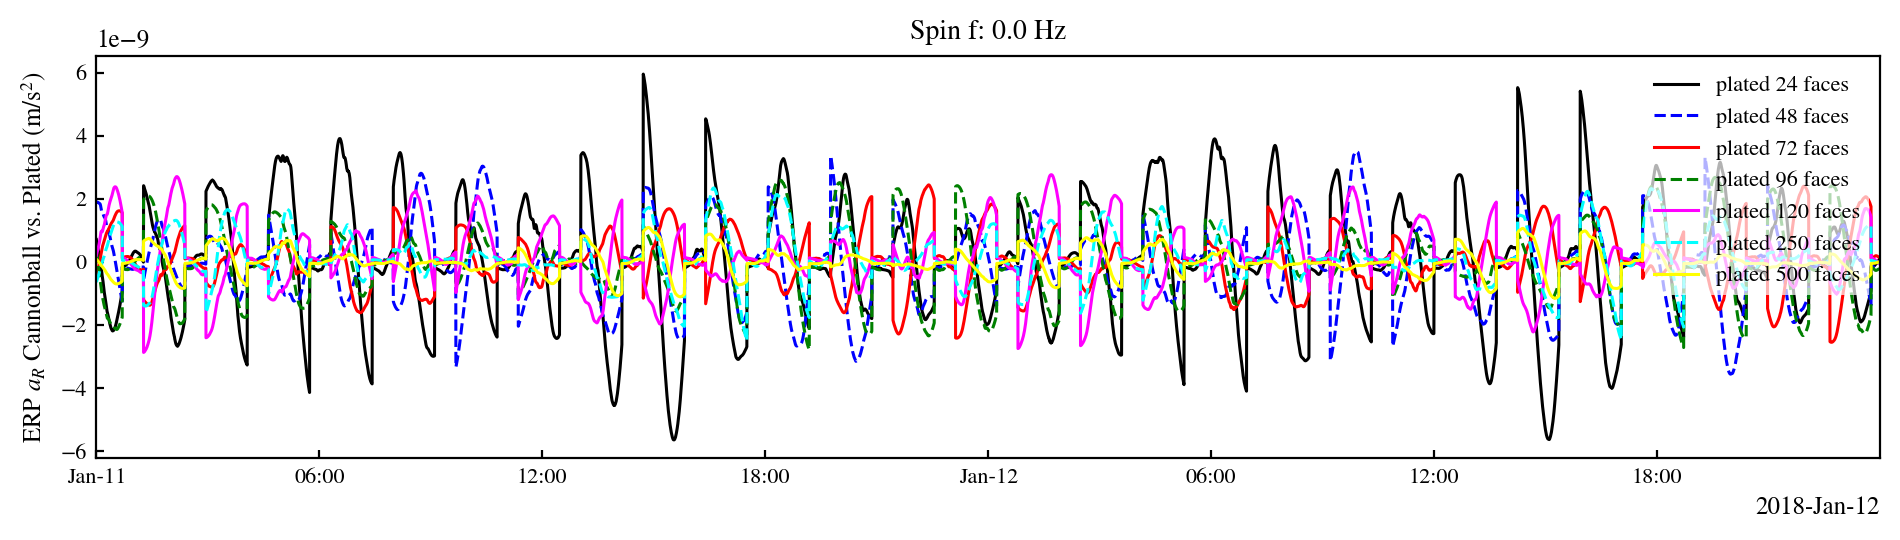

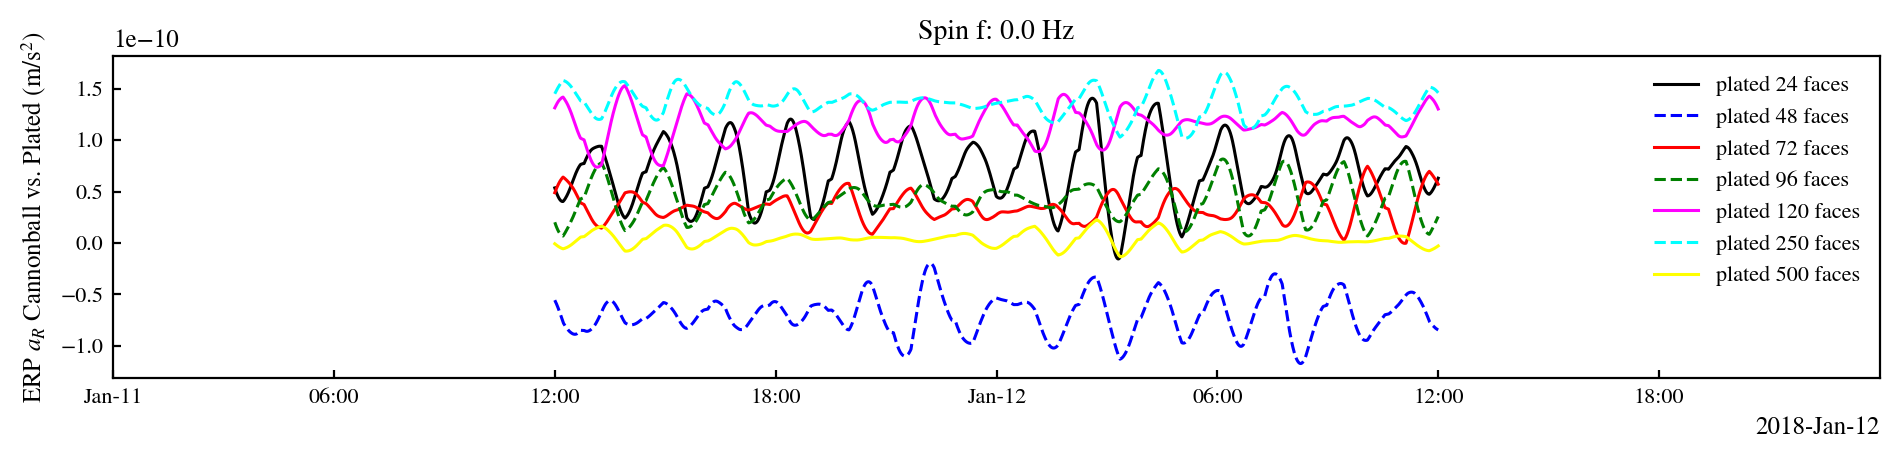

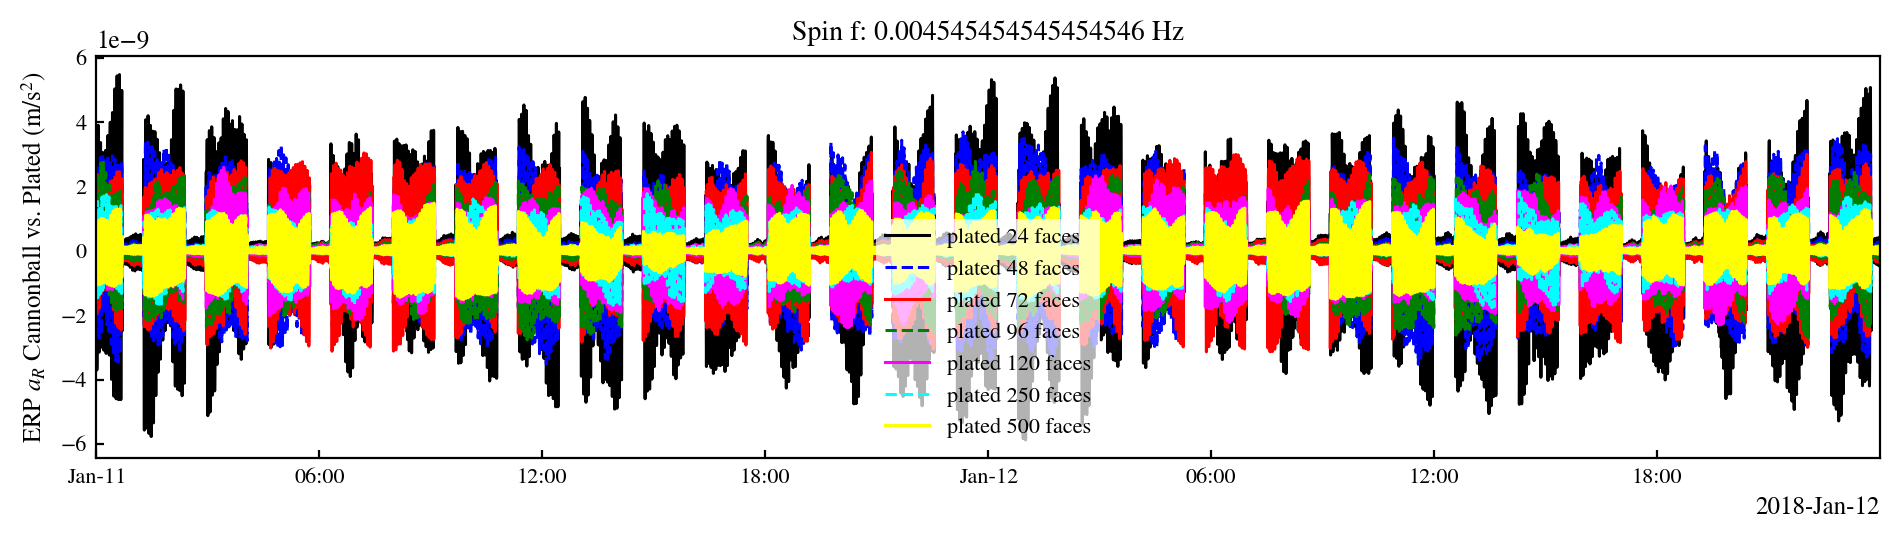

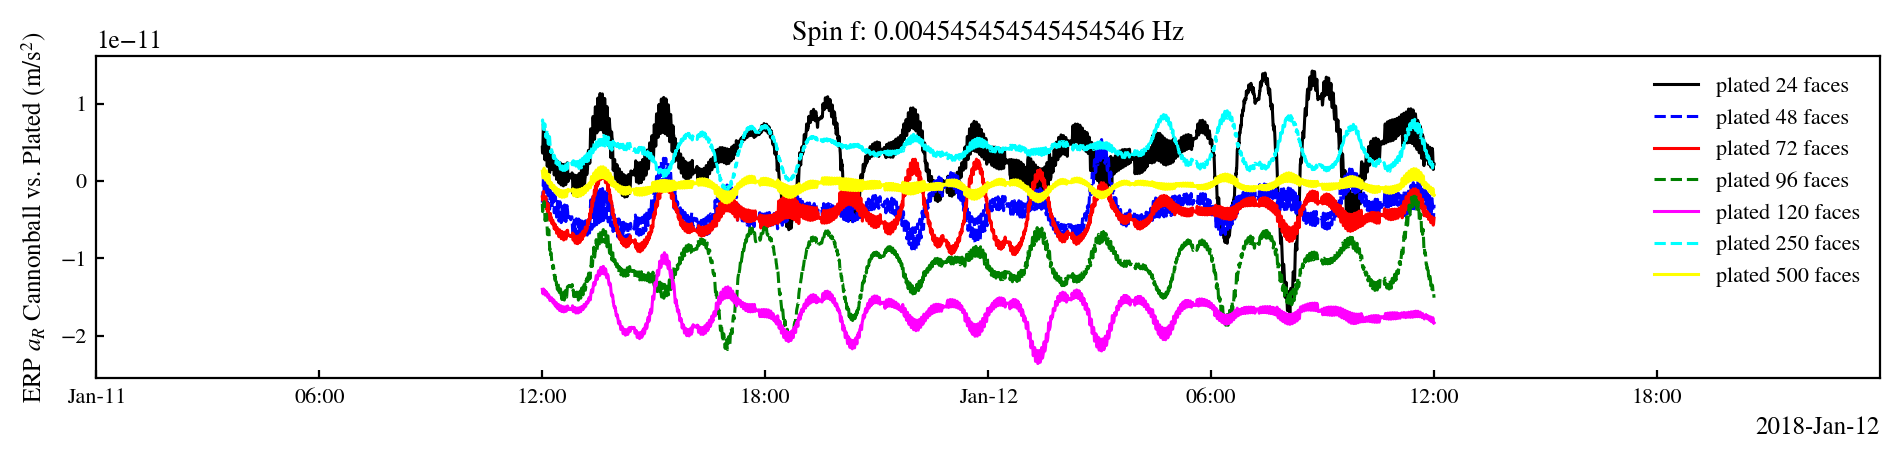

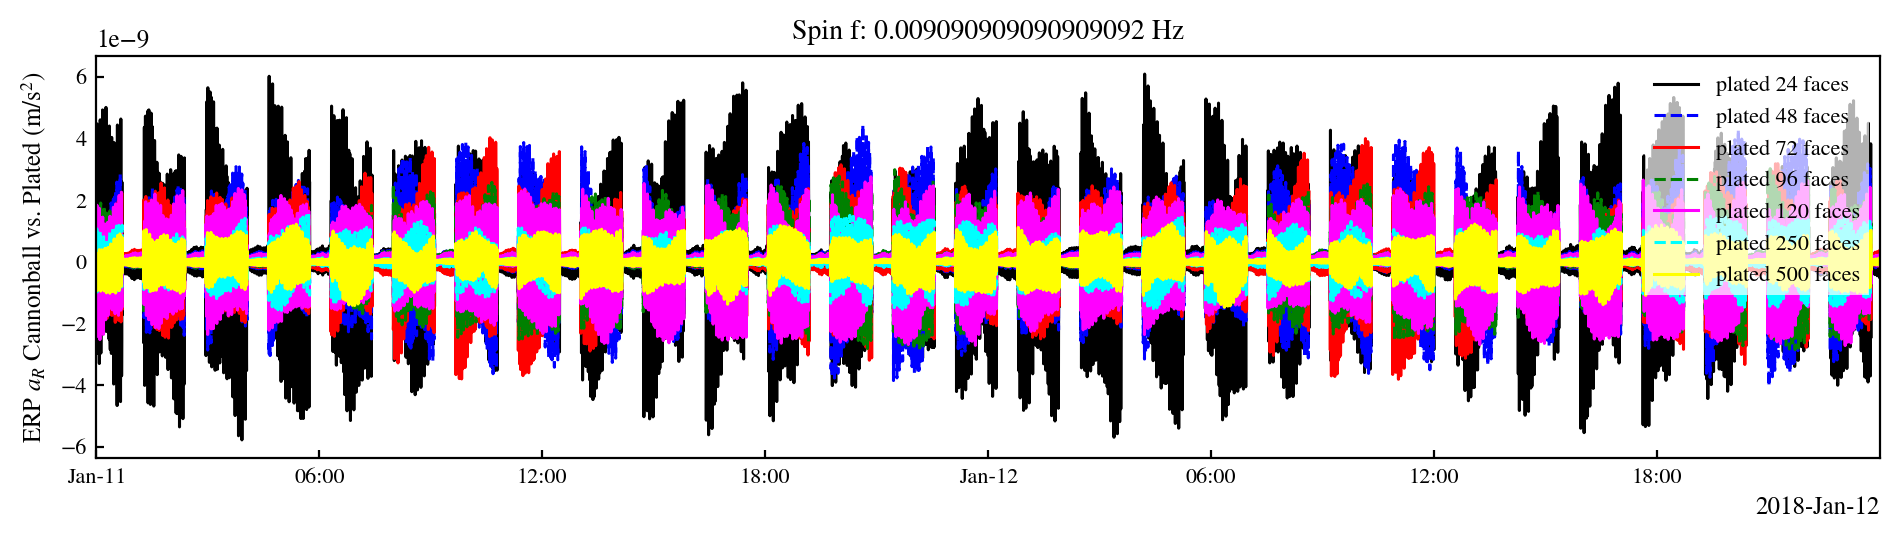

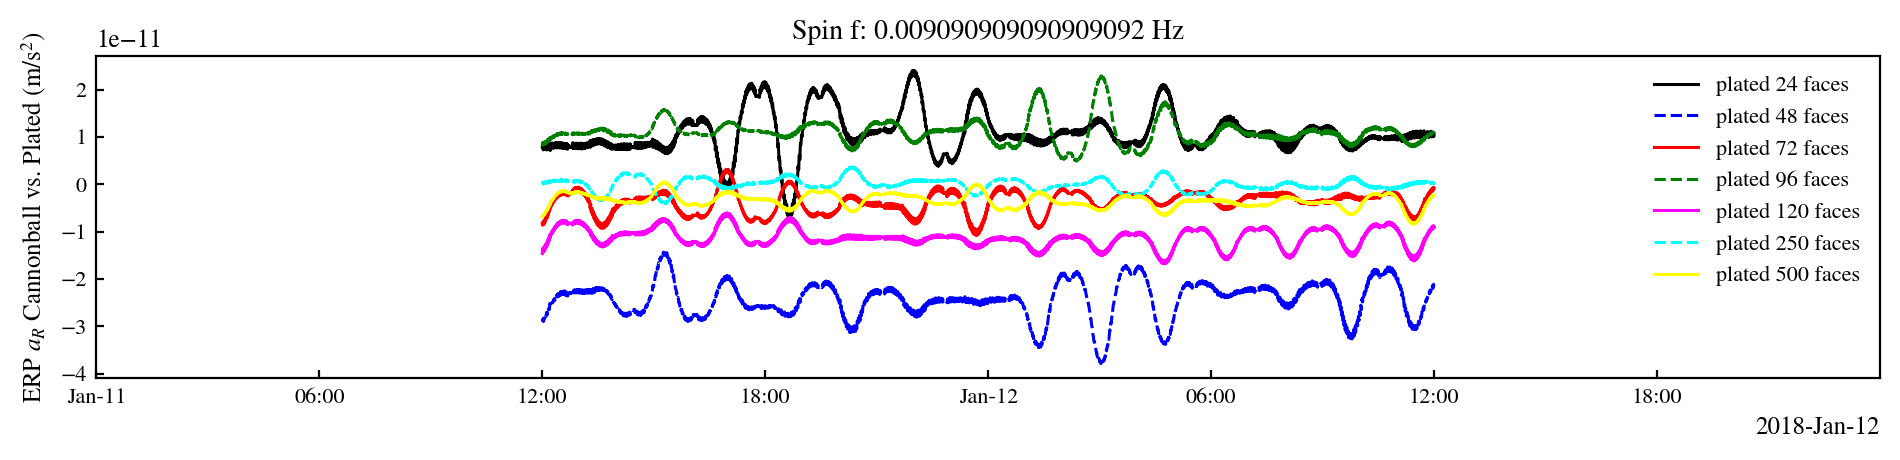

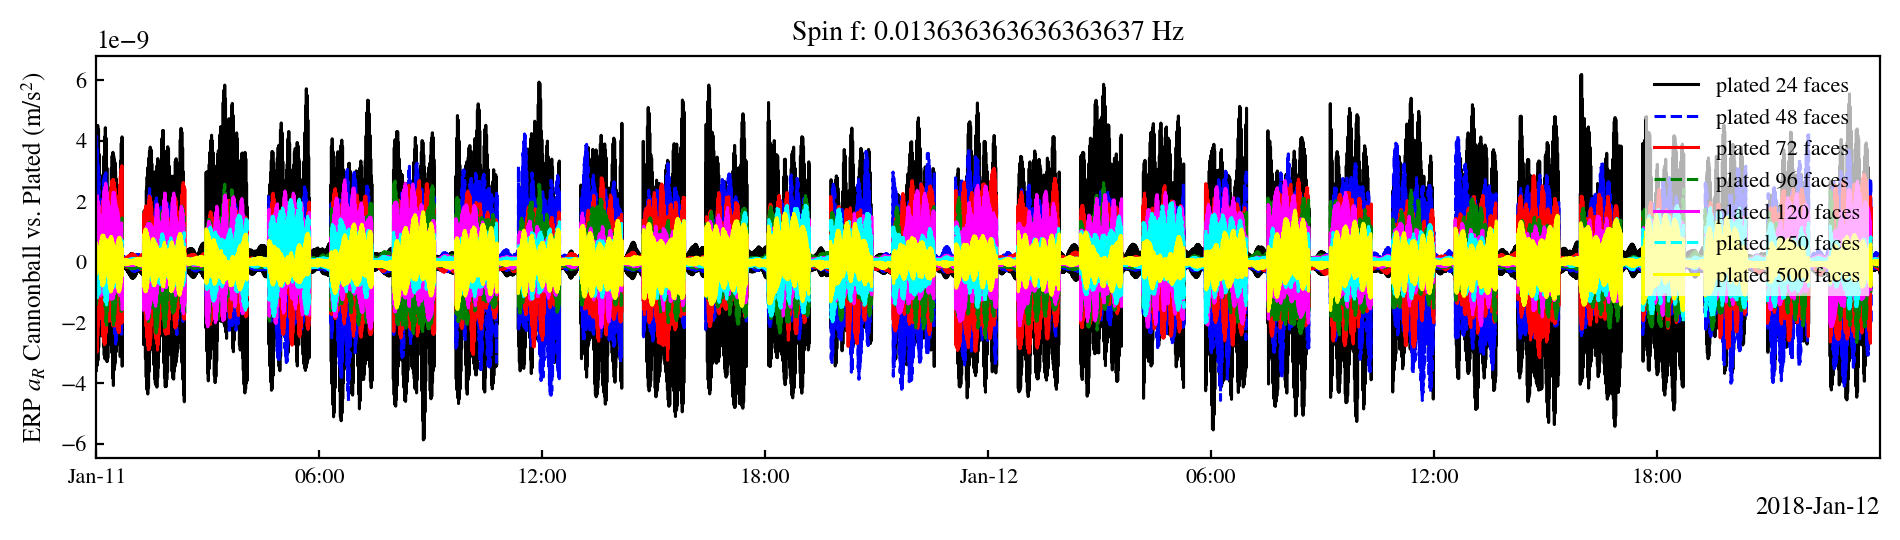

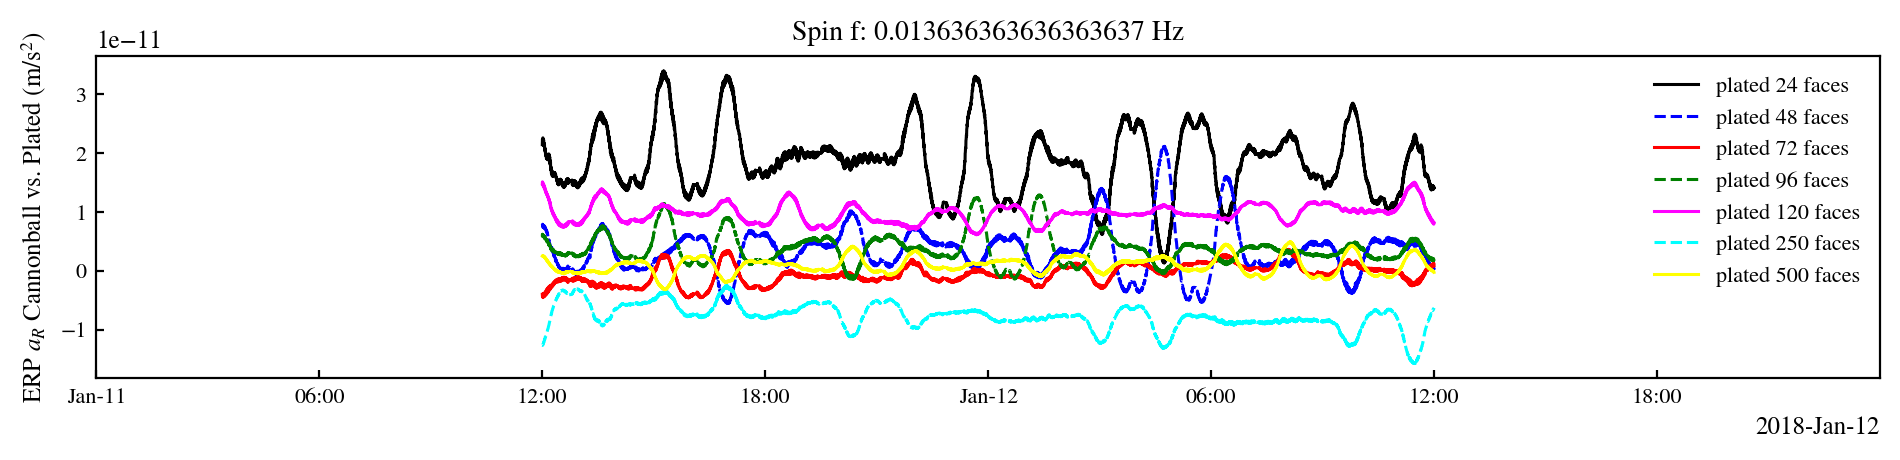

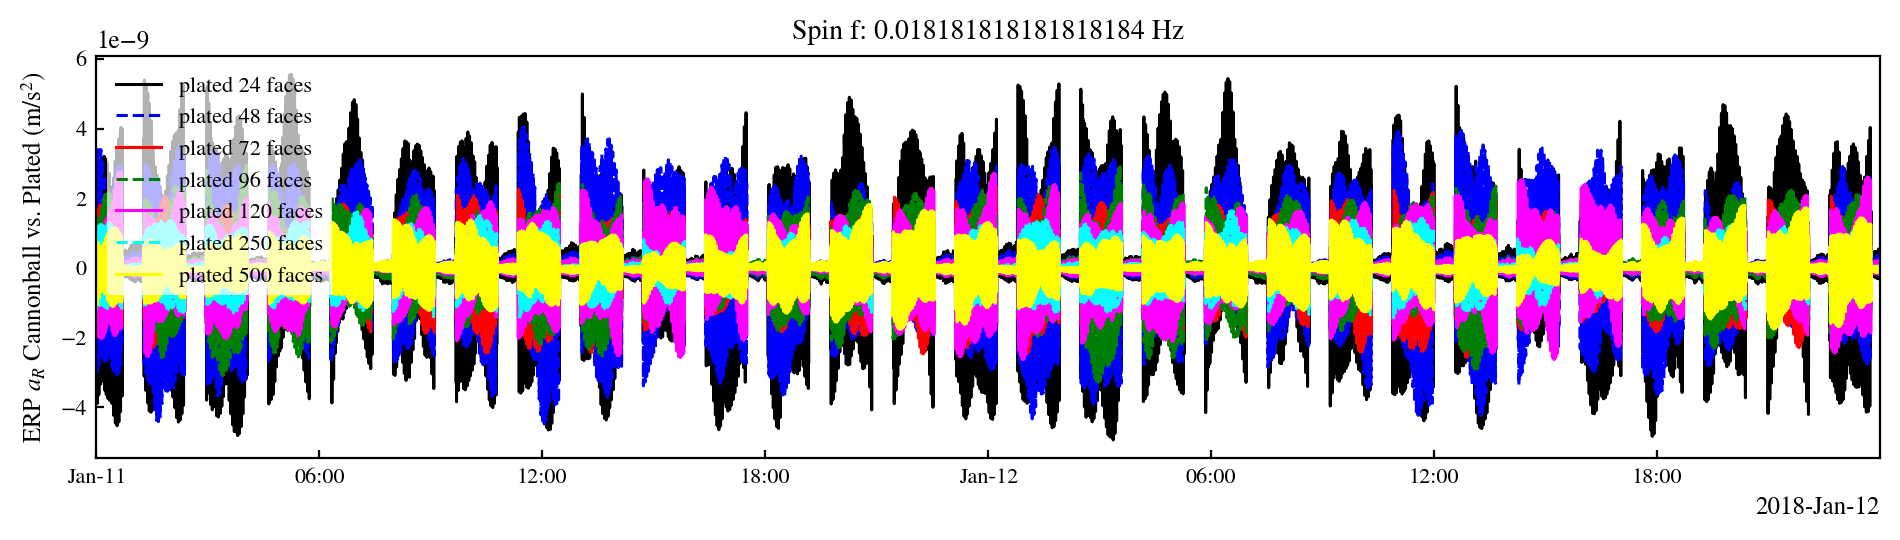

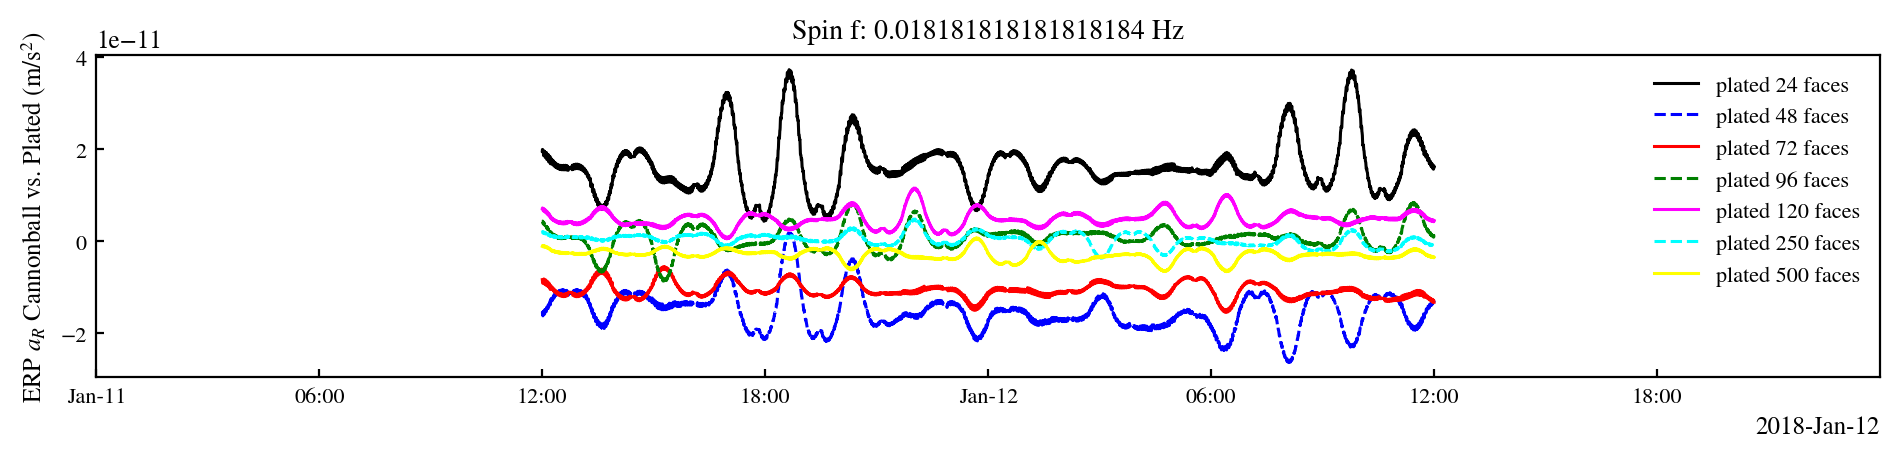

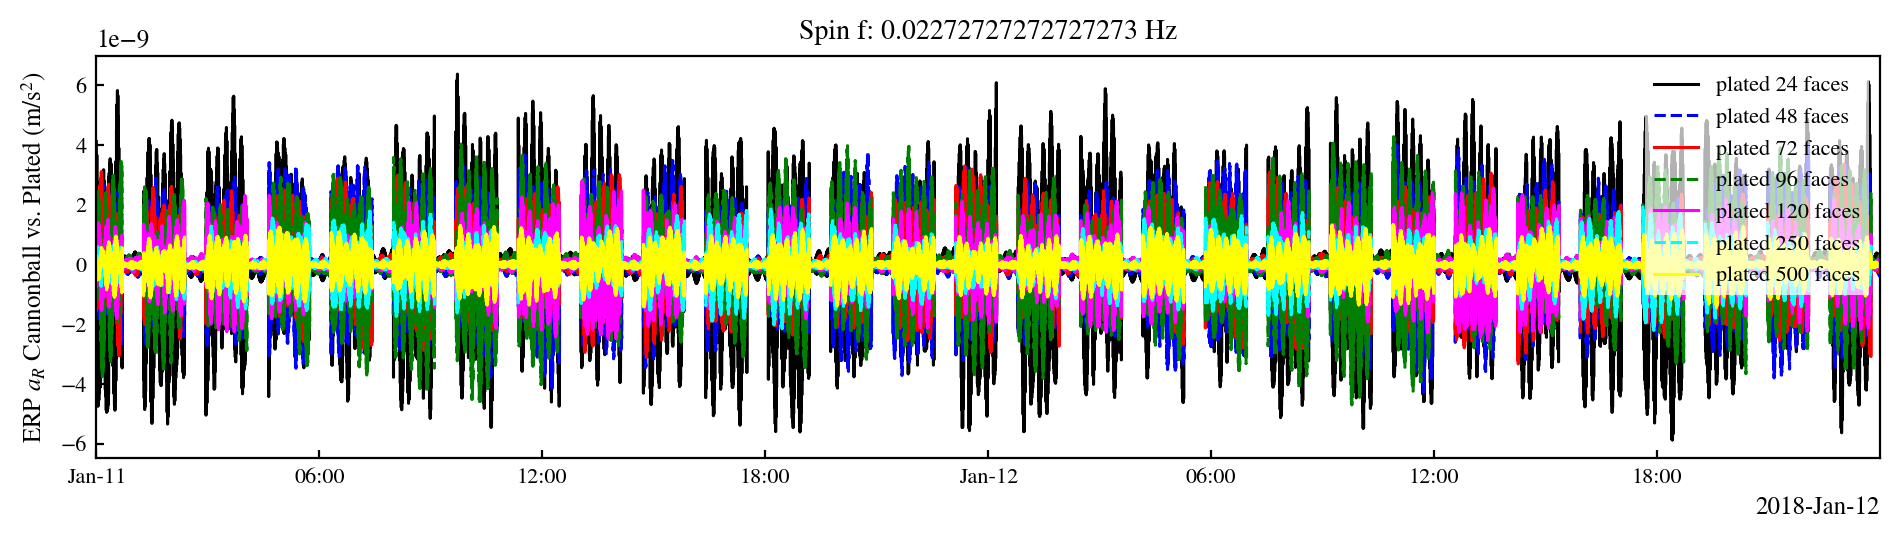

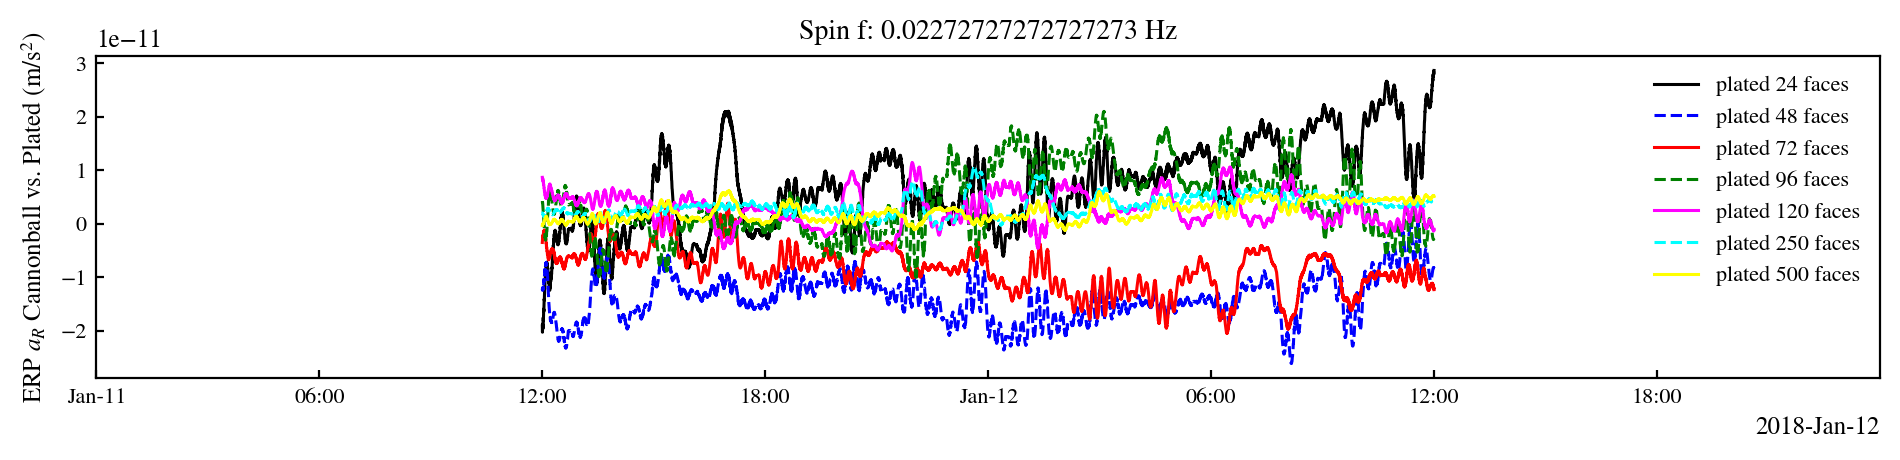

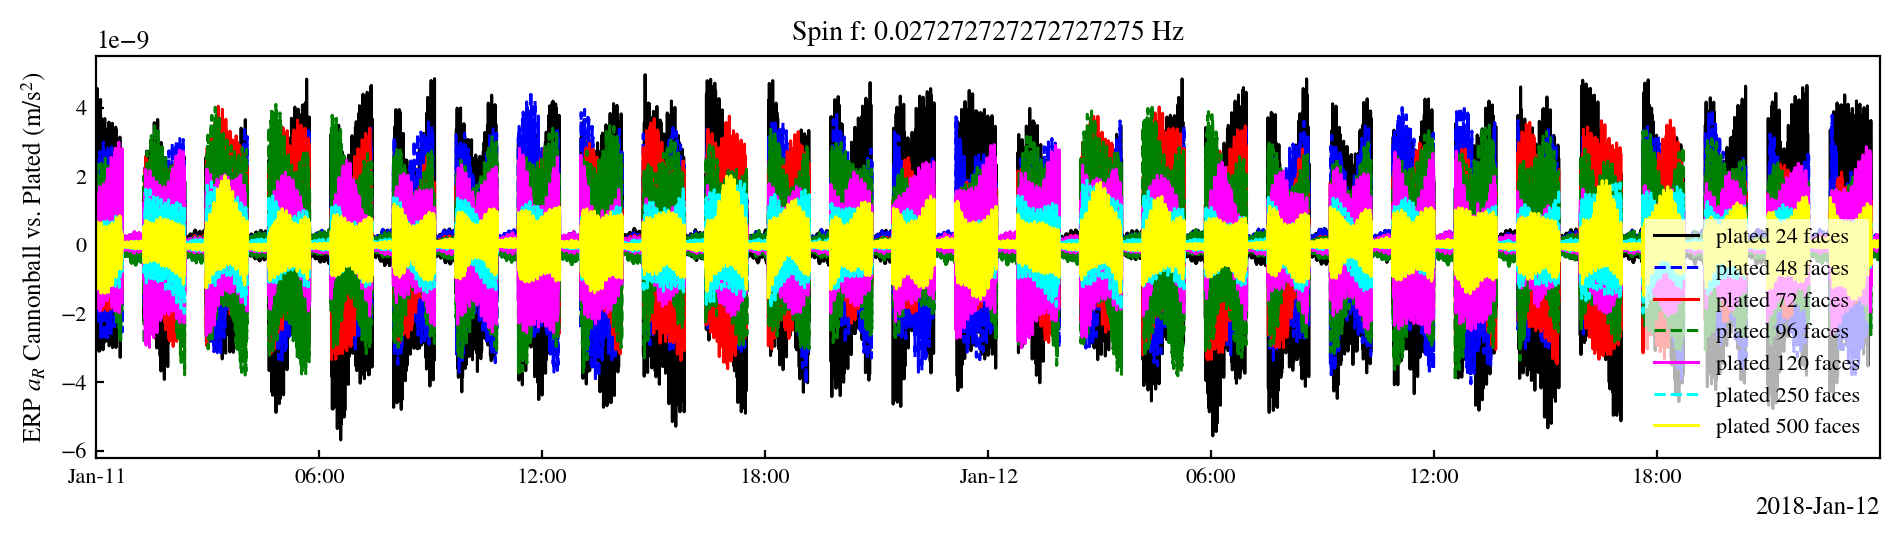

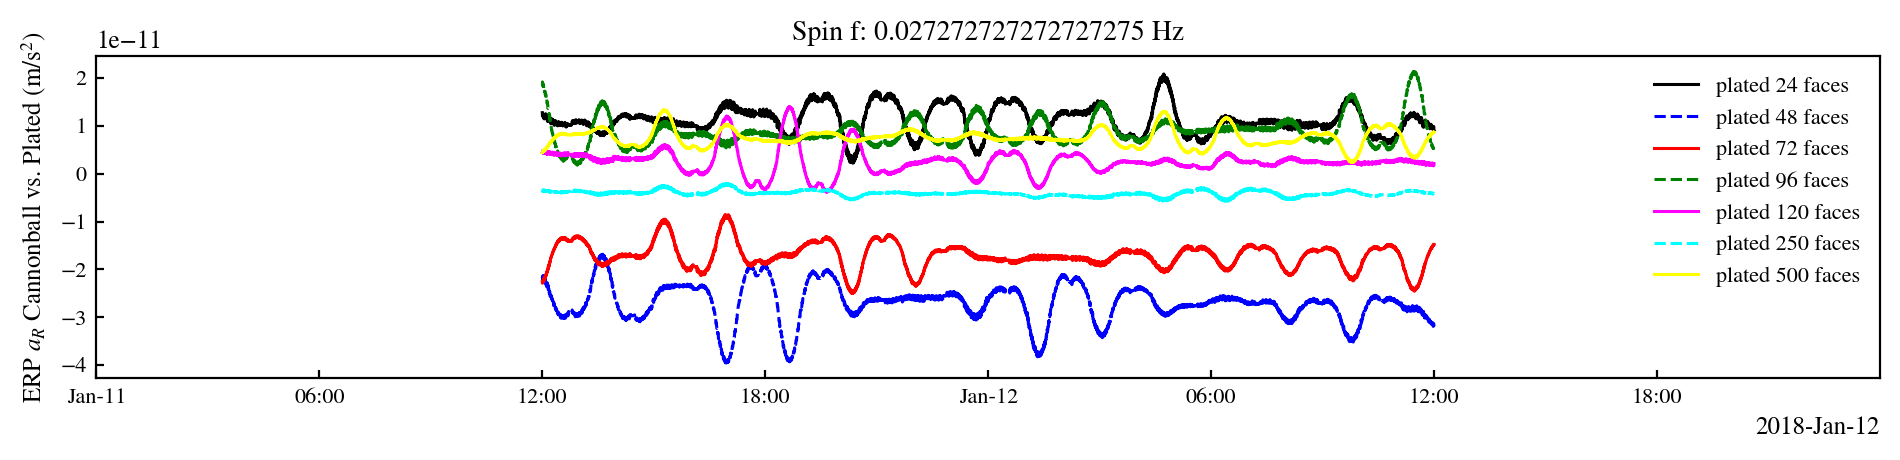

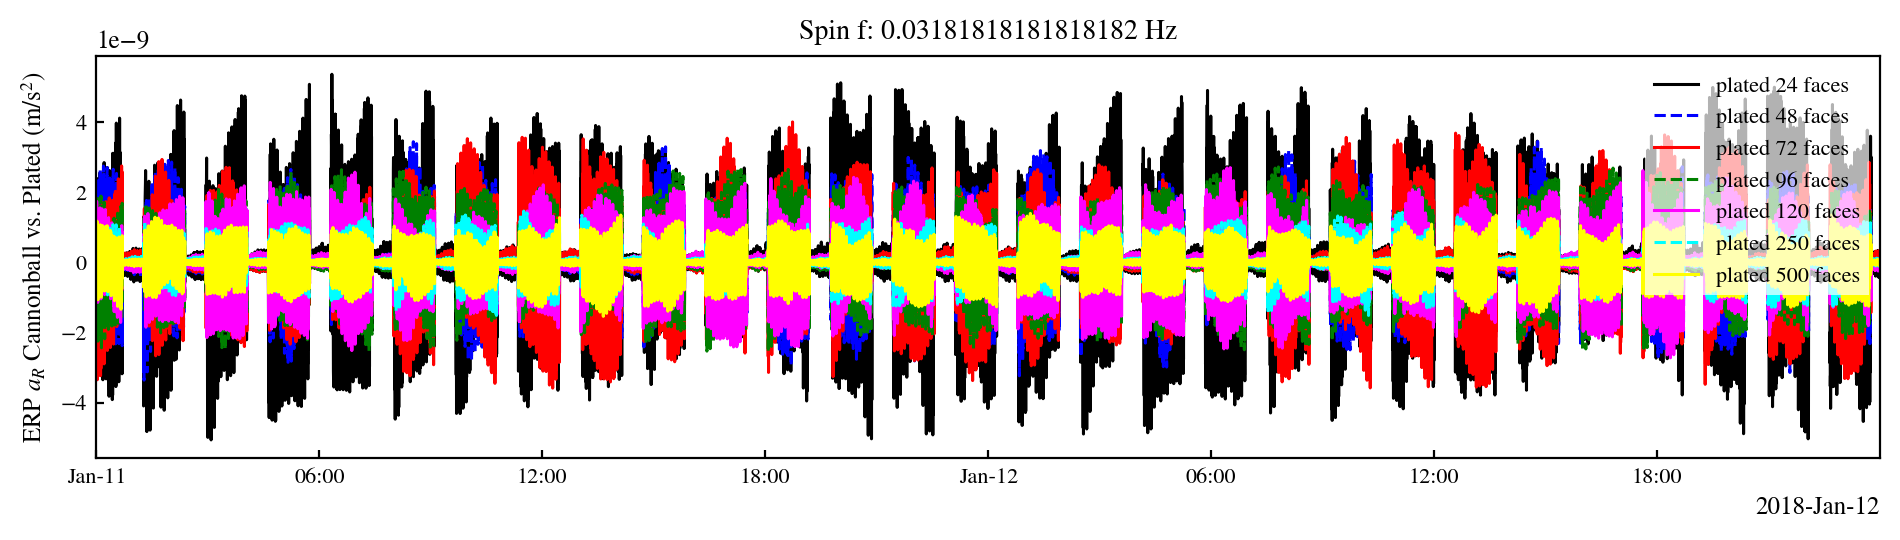

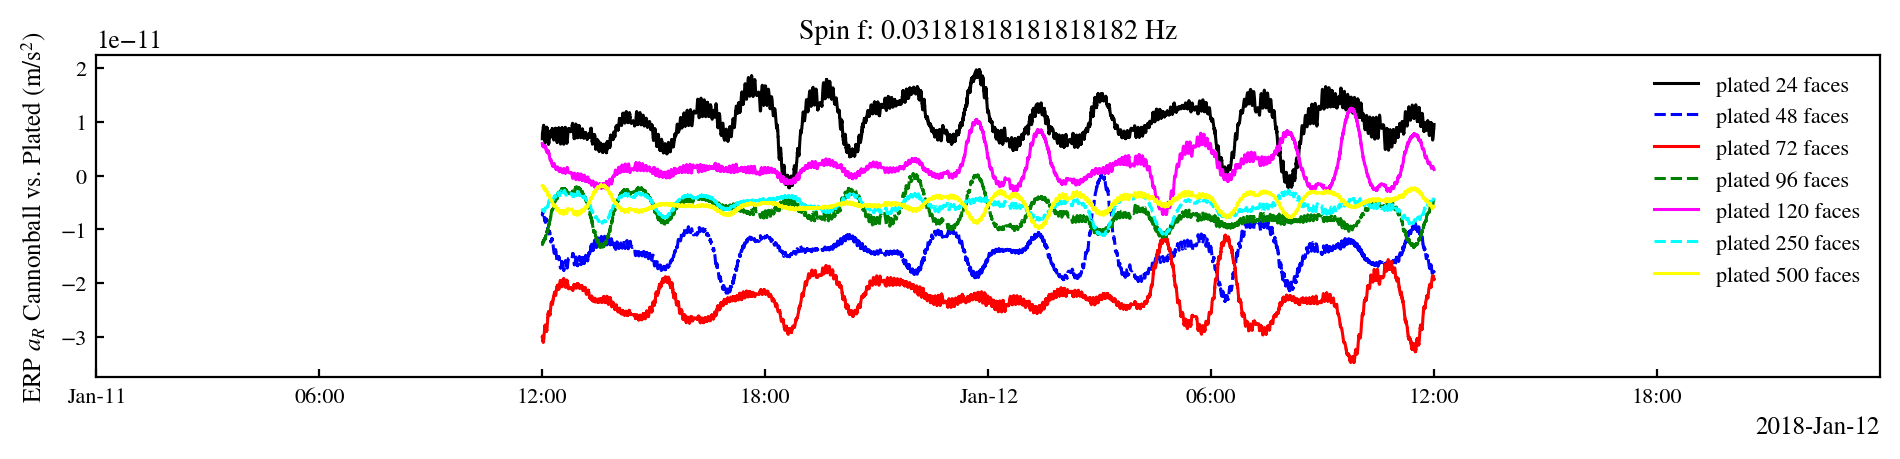

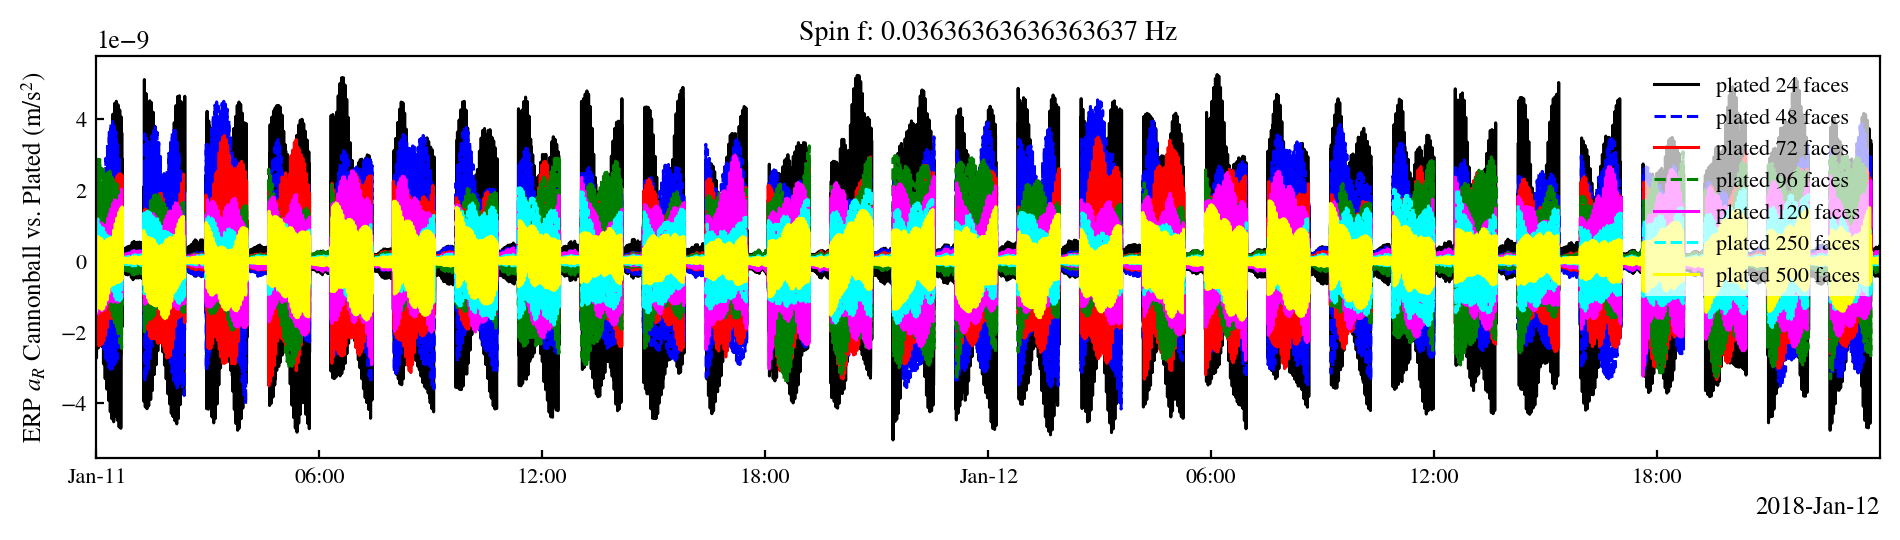

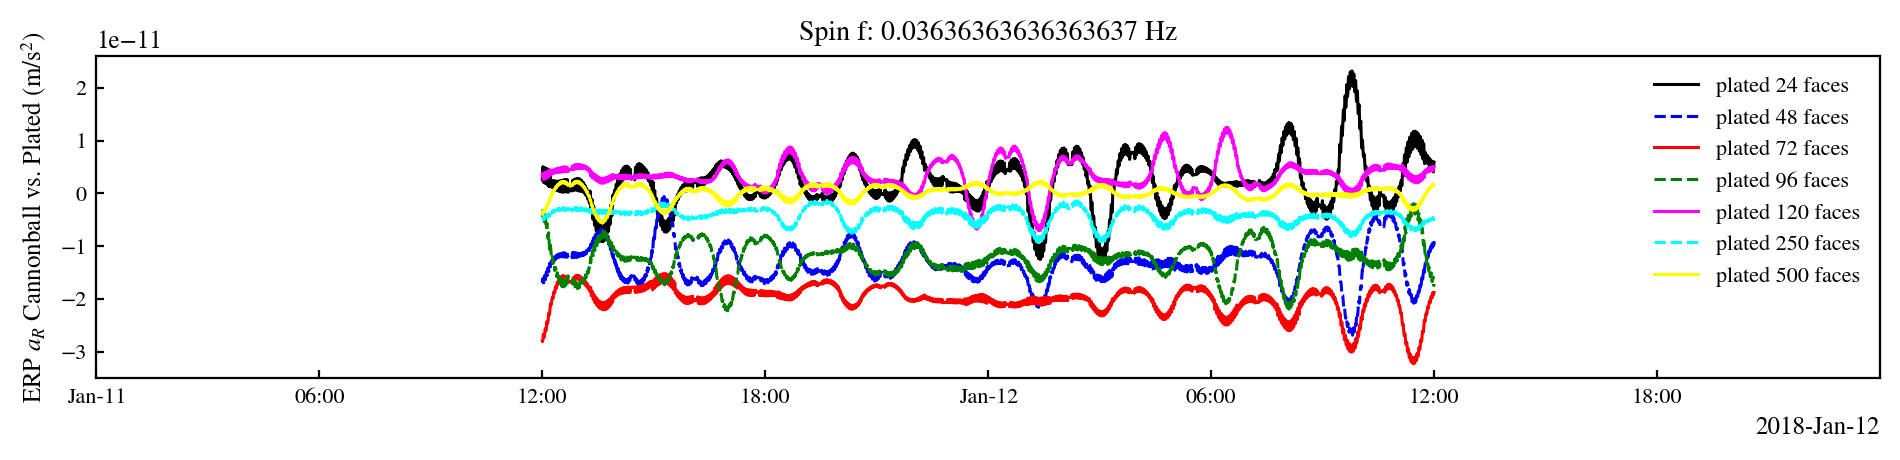

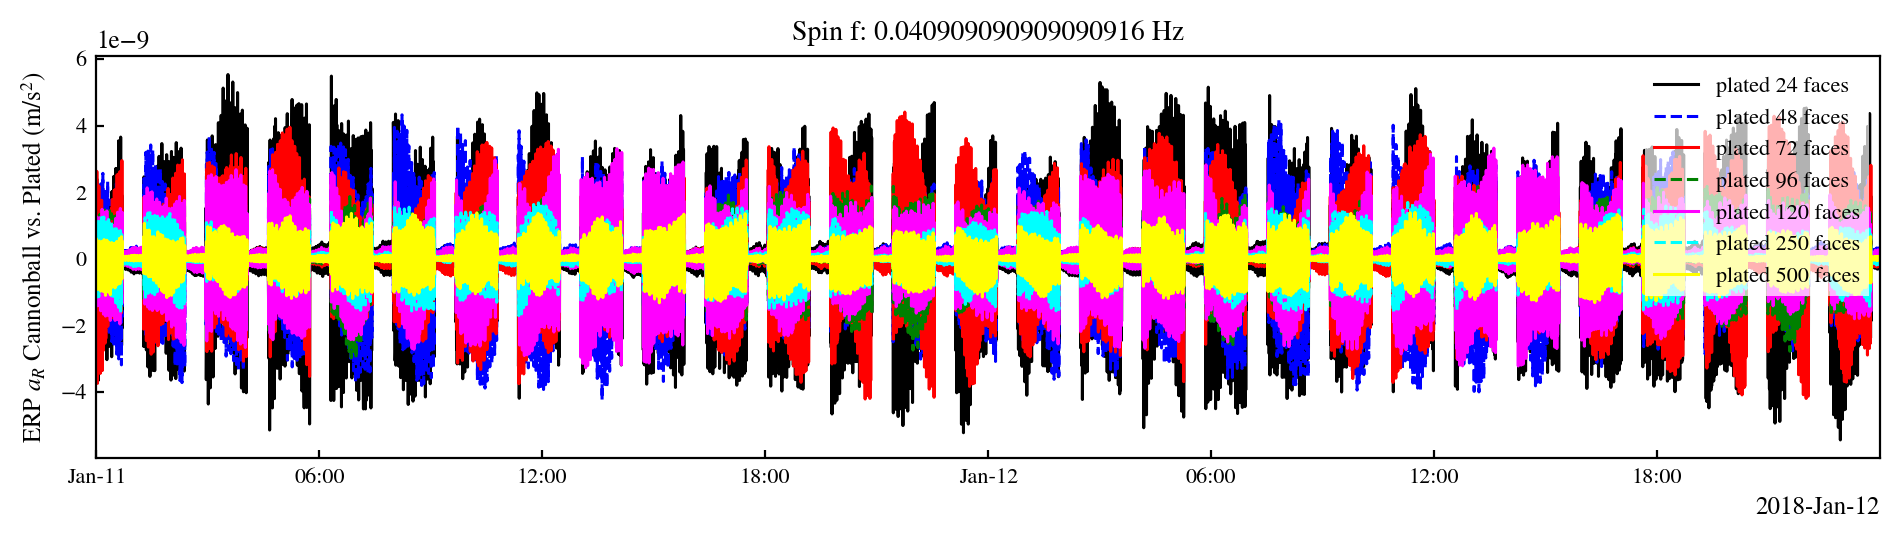

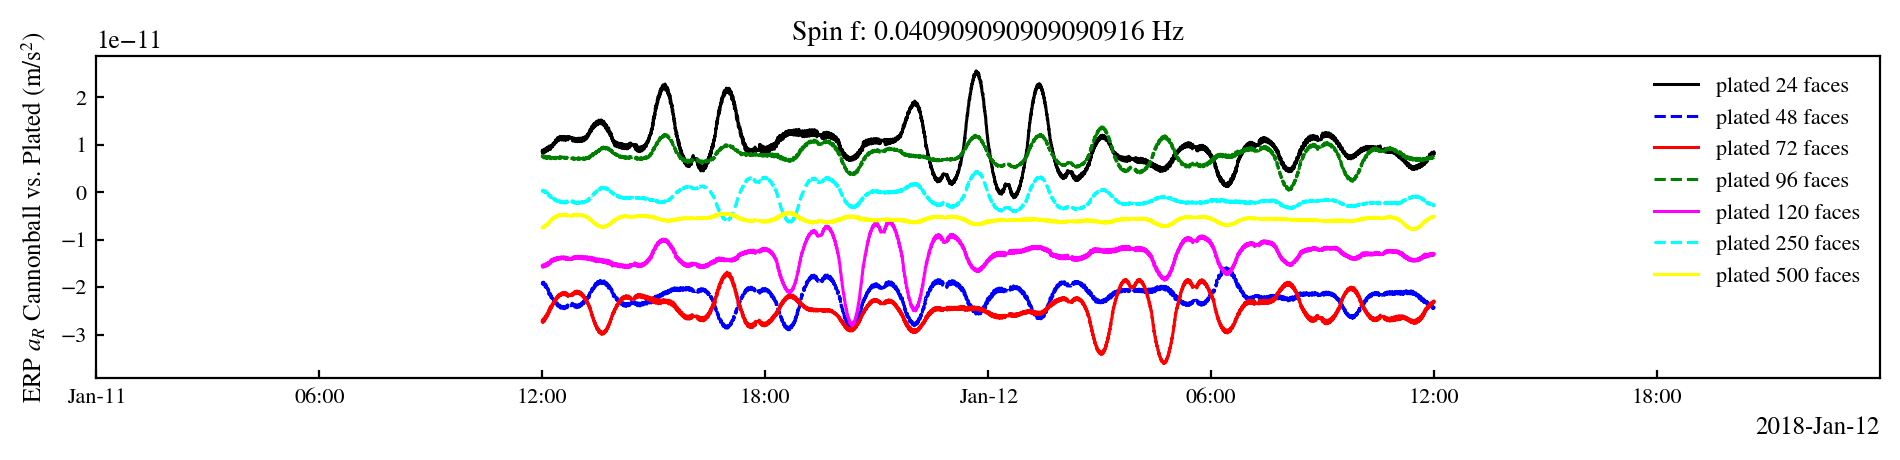

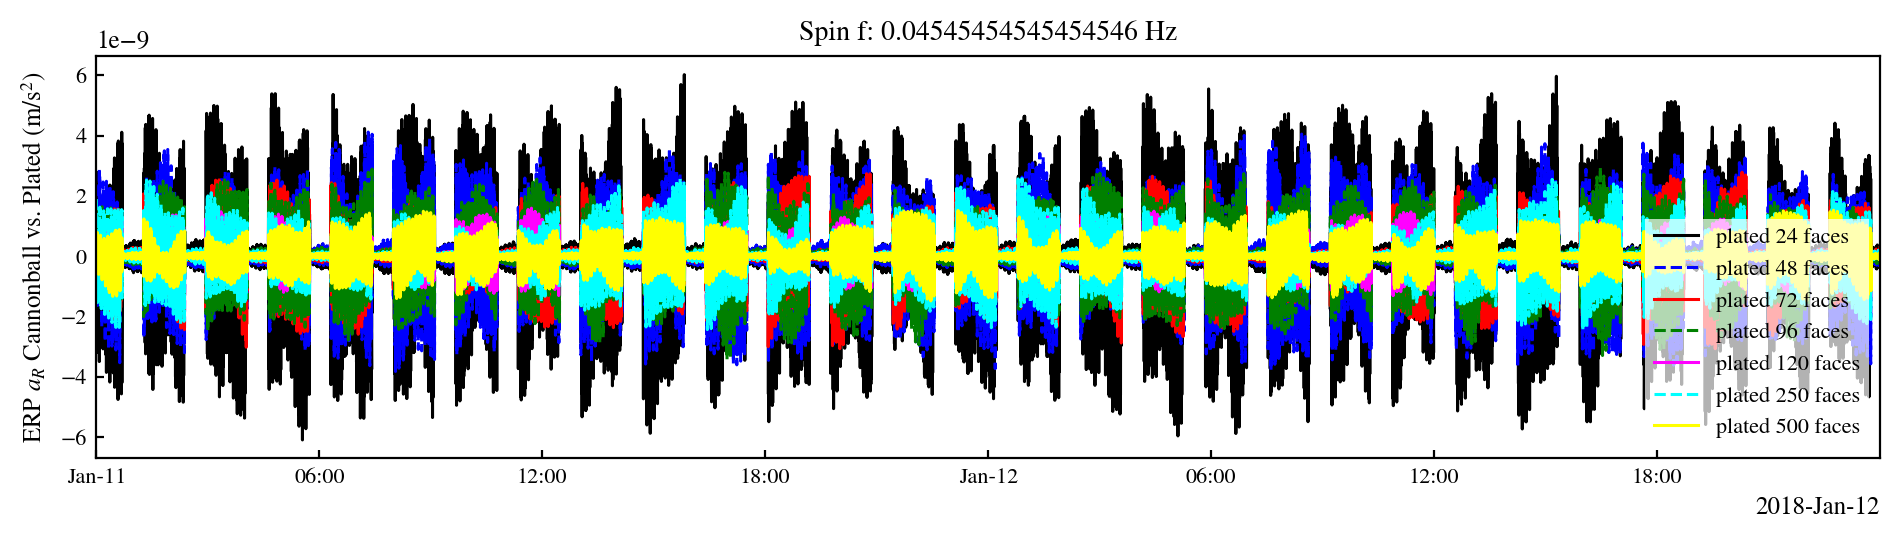

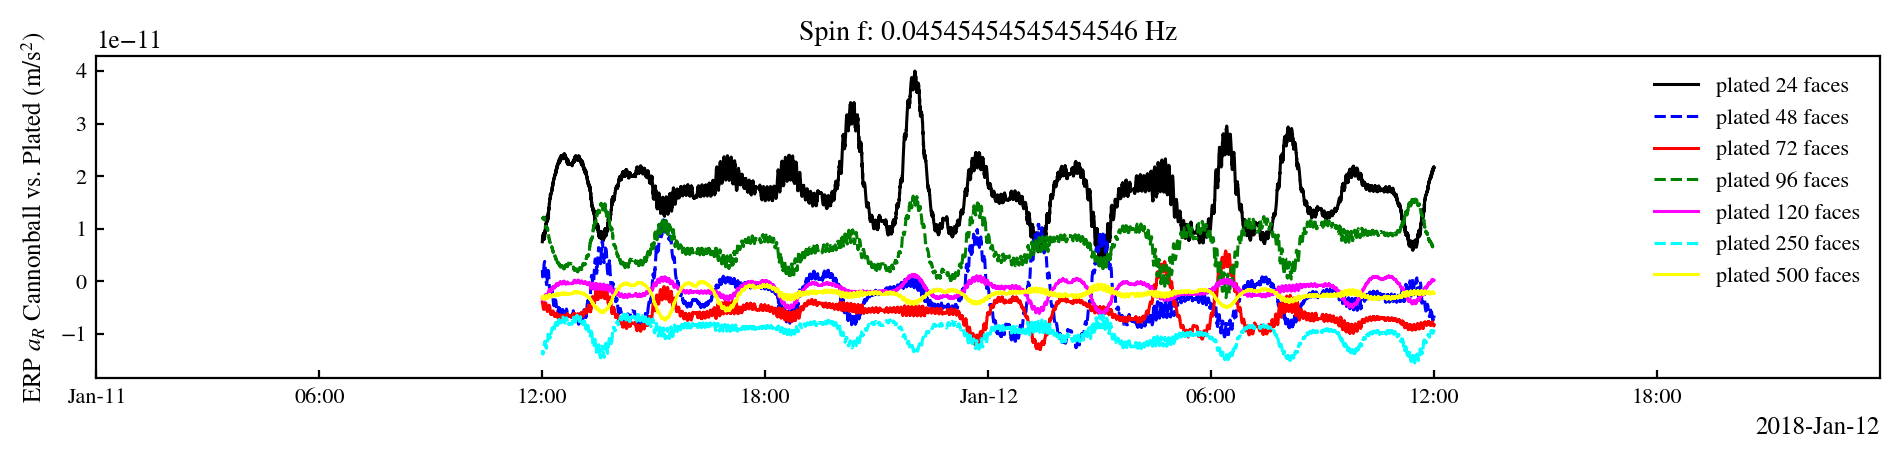

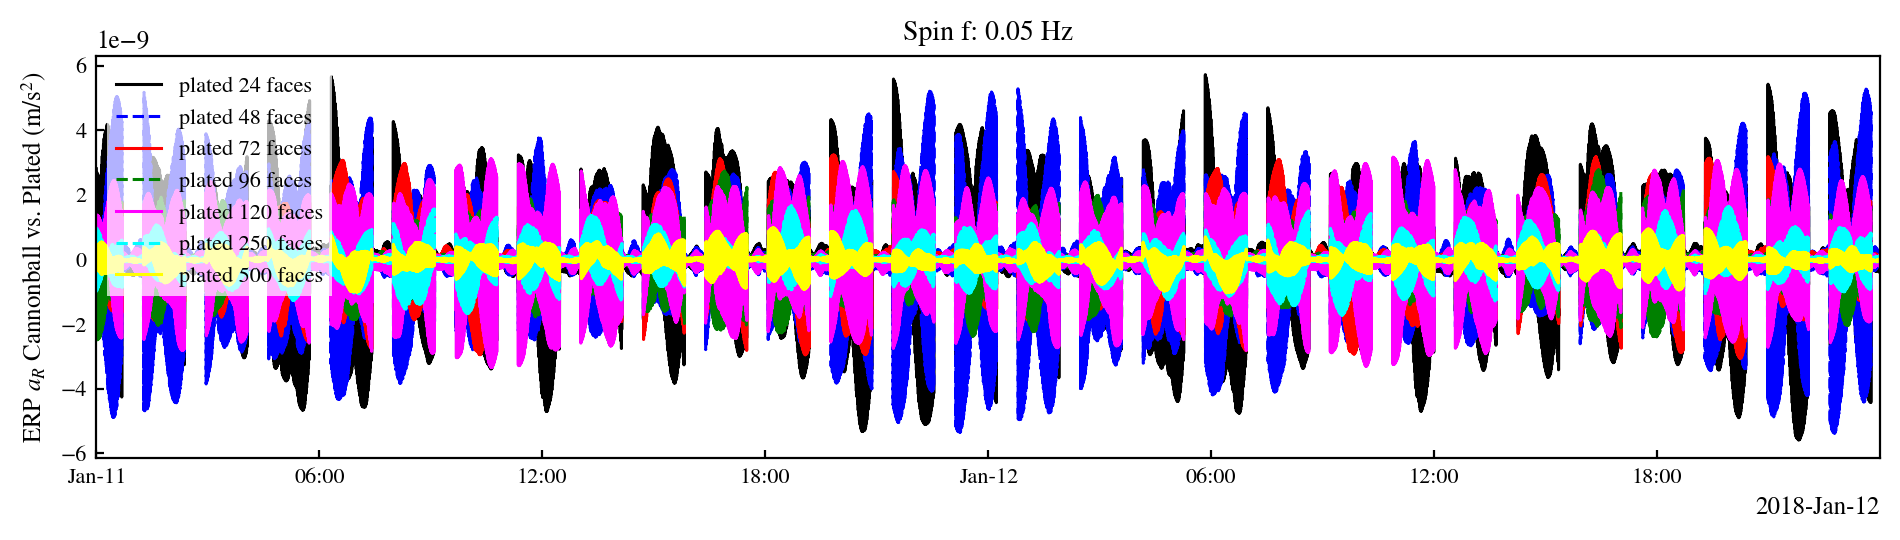

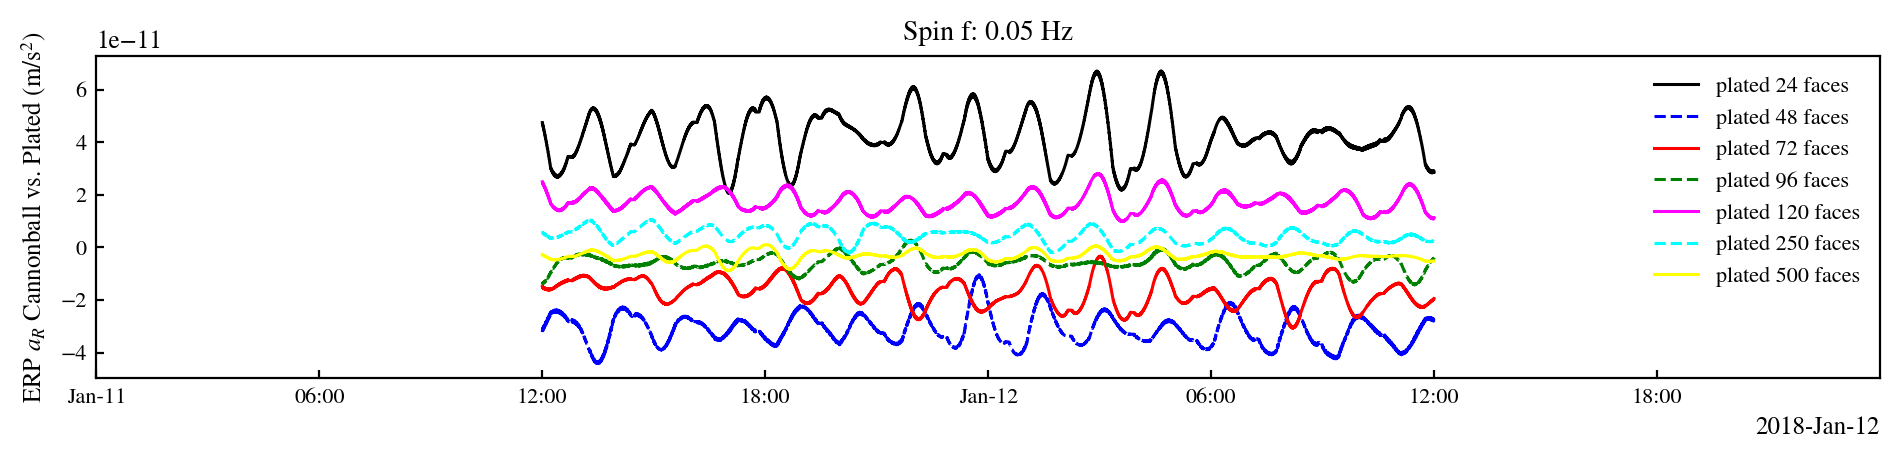

In [3]:

n_faces_array = [24, 48,72, 96, 120, 250, 500]
spin_f_array = np.linspace(0, 0.05, 12) #[0, 0.05, 0.015, 0.03] # = 0.015 # [Hz]
solar_panel_fracs = [0.5]

all_bias = np.zeros((len(spin_f_array), len(n_faces_array), len(solar_panel_fracs)))
all_rms = np.zeros((len(spin_f_array), len(n_faces_array), len(solar_panel_fracs)))

for k, solar_panel_frac in enumerate(solar_panel_fracs):

    for i, spin_f in enumerate(spin_f_array):
        print(f"SPIN FREQ.: {spin_f} HZ")
        all_net_diffs = {}
        all_net_diffs_smooth = {}
        all_net_cannonball = {}
        all_net_plated = {}

        for j, n_faces in enumerate(n_faces_array):
            mesh = get_faceted_sphere_mesh(sat_radius, n_faces, default_golden=False)
            vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh

            solar_panel_mask = select_solar_panel_facets(mesh, solar_panel_frac, distribution_mode="random")

            ca_SW = 0.12
            cd_SW = 0.2
            cs_SW = 0.68

            ca_SW_solar = 0.65
            cd_SW_solar = 0.3
            cs_SW_solar = 0.05

            sat_dict = {'mass': mass,
                        'coeff_wl_split': False,
                        'plate_normals': normal_vecs,
                        'plate_areas': areas,
                        'plate_ca_SW': ca_SW * np.ones(n_faces),
                        'plate_cd_SW': cd_SW * np.ones(n_faces),
                        'plate_cs_SW': cs_SW * np.ones(n_faces)
                        }
            sat_dict['plate_ca_SW'][solar_panel_mask] = ca_SW_solar
            sat_dict['plate_cd_SW'][solar_panel_mask] = cd_SW_solar
            sat_dict['plate_cs_SW'][solar_panel_mask] = cs_SW_solar

            net_cannonball, net_plated = compute_a_plated_vs_cannonball(sat_dict, spin_f)
            all_net_cannonball[f"plated {n_faces} faces"] = net_cannonball
            all_net_plated[f"plated {n_faces} faces"] = net_plated

            net_diff = net_cannonball-net_plated
            net_diff_smooth = normal_smoother(net_diff, np.concatenate(all_jd), 1, out_length_mode='same_with_nans')
            all_net_diffs[f"plated {n_faces} faces"] = net_diff
            all_net_diffs_smooth[f"plated {n_faces} faces"] = net_diff_smooth

            all_bias[i,j,k] = np.mean(net_diff)
            all_rms[i,j,k] = nanrms(net_diff)

        Plotter.plot_time_series(np.concatenate(all_jd), 
                                all_net_diffs,
                                ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                                f_width=2.4, f_height=0.7,
                                title=f"Spin f: {spin_f} Hz")
        
        Plotter.plot_time_series(np.concatenate(all_jd), 
                                all_net_diffs_smooth,
                                ylabel='ERP $a_R$ Cannonball vs. Plated (m/s$^2$)',
                                f_width=2.4, f_height=0.6,
                                title=f"Spin f: {spin_f} Hz")


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, SymLogNorm

USE_LOG_SCALES = False  # False: all linear; True: symlog bias / log RMS (curves and colours).

# Work on sorted copies, preserving the sweep arrays for subsequent analysis.
plate_order = np.argsort(n_faces_array)
frequency_order = np.argsort(spin_f_array)
plate_counts = np.asarray(n_faces_array)[plate_order]
spin_frequencies = np.asarray(spin_f_array)[frequency_order]
expected_shape = (len(spin_f_array), len(n_faces_array))
if np.shape(all_bias) != expected_shape or np.shape(all_rms) != expected_shape:
    raise ValueError("Run the sweep first: bias/RMS shapes must match the frequency and plate arrays.")
bias_by_spin = np.asarray(all_bias)[np.ix_(frequency_order, plate_order)]
rms_by_spin = np.asarray(all_rms)[np.ix_(frequency_order, plate_order)]


def _style_sweep_axes(ax, ylabel):
    ax.set_xlabel('Number of plates', fontsize=Plotter.font_size)
    ax.set_ylabel(ylabel, fontsize=Plotter.font_size)
    ax.set_xticks(plate_counts)
    ax.grid(False)
    ax.tick_params(direction='in', length=3, width=0.8,
                   labelsize=Plotter.font_size_red)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def _sweep_cell_edges(values):
    # Preserve unequal parameter spacing; also support a single sampled value.
    values = np.asarray(values, dtype=float)
    if len(values) == 1:
        half_width = abs(values[0]) / 2 if values[0] else 0.5
        return np.array([max(0, values[0] - half_width), values[0] + half_width])
    midpoints = (values[:-1] + values[1:]) / 2
    return np.r_[max(0, values[0] - (midpoints[0] - values[0])),
                 midpoints, values[-1] + (values[-1] - midpoints[-1])]


# Keep handles available for saving or adjusting individual figures.
sweep_figures = {}
for metric, values in [('Bias', bias_by_spin), ('RMS', rms_by_spin)]:
    # Use the same scale parameters for the curves and the heat map.
    finite_values = values[np.isfinite(values)]
    vmax = np.max(np.abs(finite_values)) if finite_values.size else 0.0
    vmax = vmax if vmax > 0 else np.finfo(float).eps
    plot_values = np.ma.masked_invalid(values)
    if not USE_LOG_SCALES:
        norm = Normalize(vmin=-vmax if metric == 'Bias' else 0, vmax=vmax)
    elif metric == 'Bias':
        # Linear within 1% of the largest absolute bias; logarithmic outside.
        bias_linthresh = max(0.01 * vmax, np.finfo(float).tiny)
        norm = SymLogNorm(linthresh=bias_linthresh, vmin=-vmax, vmax=vmax, base=10)
    else:
        # Zero/nonpositive RMS has no logarithm: leave these entries blank.
        plot_values = np.ma.masked_less_equal(plot_values, 0)
        positive_values = finite_values[finite_values > 0]
        vmin = np.min(positive_values) if positive_values.size else vmax / 10
        if vmin == vmax:
            vmin, vmax = vmin / 10, vmax * 10
        norm = LogNorm(vmin=vmin, vmax=vmax)

    metric_label = rf'{metric} of $\Delta a_R$ (m/s$^2$)'
    fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                    0.8 * Plotter.fig_height), dpi=200)
    for i, spin_f in enumerate(spin_frequencies):
        ax.plot(plate_counts, plot_values[i], label=f'{spin_f:g} Hz',
                color=Plotter.line_colors[i % len(Plotter.line_colors)],
                linestyle=Plotter.linestyles[i % len(Plotter.linestyles)],
                linewidth=Plotter.line_w, marker='o', markersize=3)
    if metric == 'Bias':
        if USE_LOG_SCALES:
            ax.set_yscale('symlog', linthresh=bias_linthresh, base=10)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    elif USE_LOG_SCALES:
        ax.set_yscale('log', base=10)
        ax.set_ylim(vmin, vmax)
    else:
        ax.set_ylim(bottom=0)
    _style_sweep_axes(ax, metric_label)
    ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
    ax.legend(title='Spin frequency', fontsize=Plotter.font_size_red,
              title_fontsize=Plotter.font_size_red, loc='best')
    fig.tight_layout()
    sweep_figures[f'{metric.lower()}_curves'] = (fig, ax)
    plt.show()

    fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                    0.8 * Plotter.fig_height), dpi=200)
    mesh = ax.pcolormesh(_sweep_cell_edges(plate_counts),
                         _sweep_cell_edges(spin_frequencies),
                         plot_values, shading='flat',
                         cmap='seismic' if metric == 'Bias' else 'plasma',
                         norm=norm)
    _style_sweep_axes(ax, 'Spin frequency (Hz)')
    ax.set_yticks(spin_frequencies)
    ax.set_yticklabels([f'{spin_f:g}' for spin_f in spin_frequencies])
    ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label(metric_label, fontsize=Plotter.font_size)
    cbar.ax.tick_params(labelsize=Plotter.font_size_red)
    fig.tight_layout()
    sweep_figures[f'{metric.lower()}_heatmap'] = (fig, ax)
    plt.show()

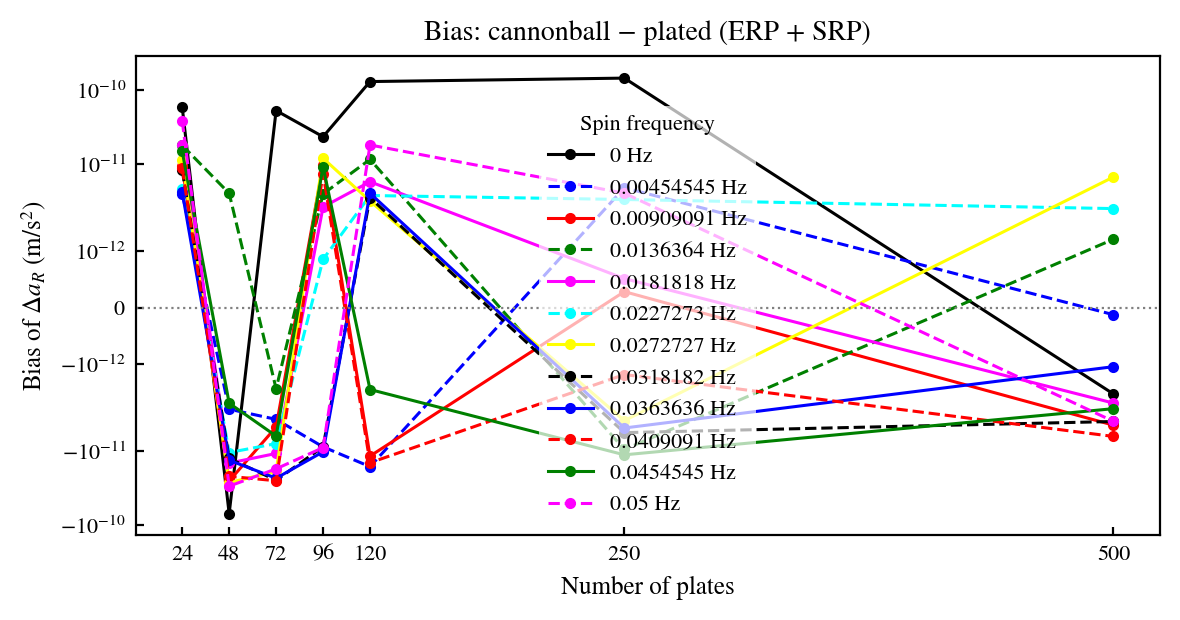

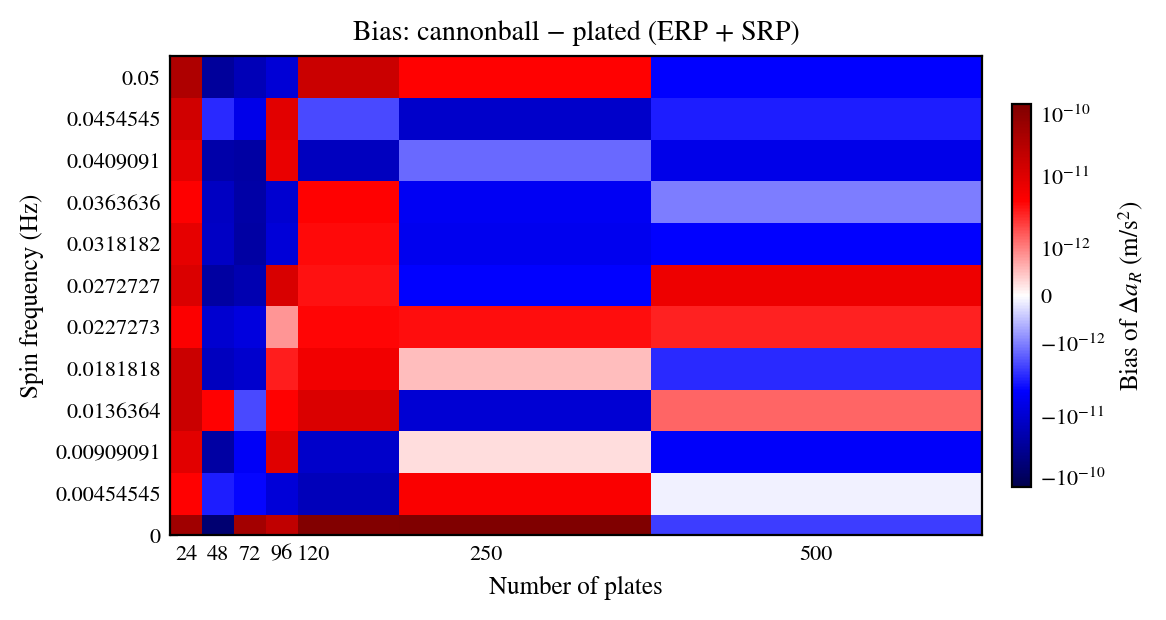

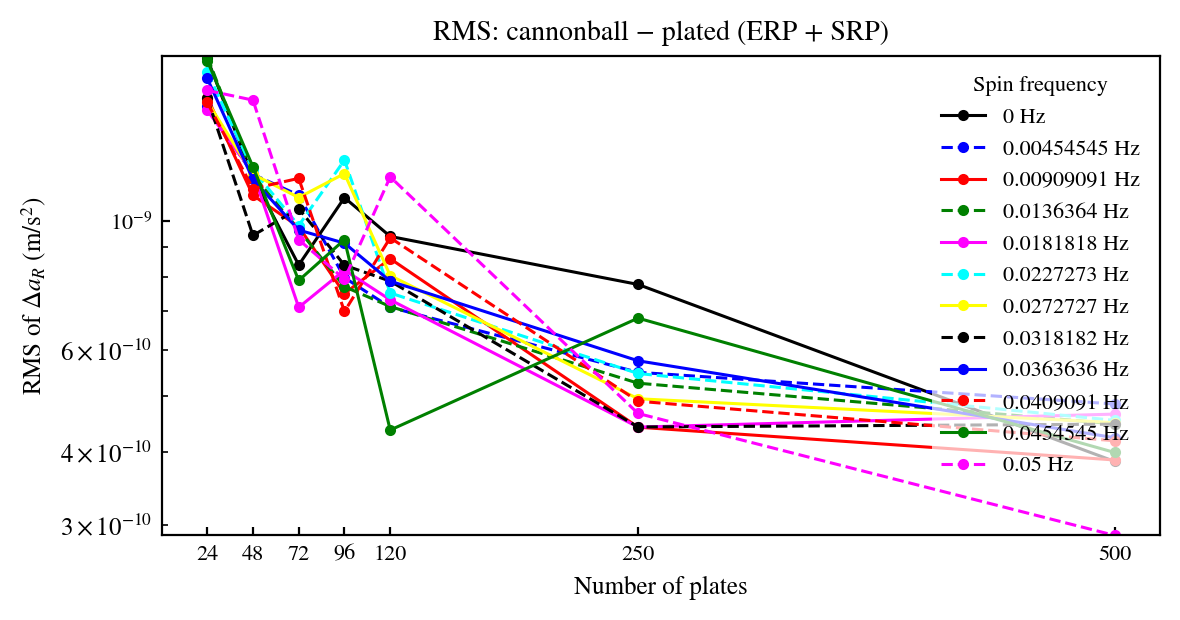

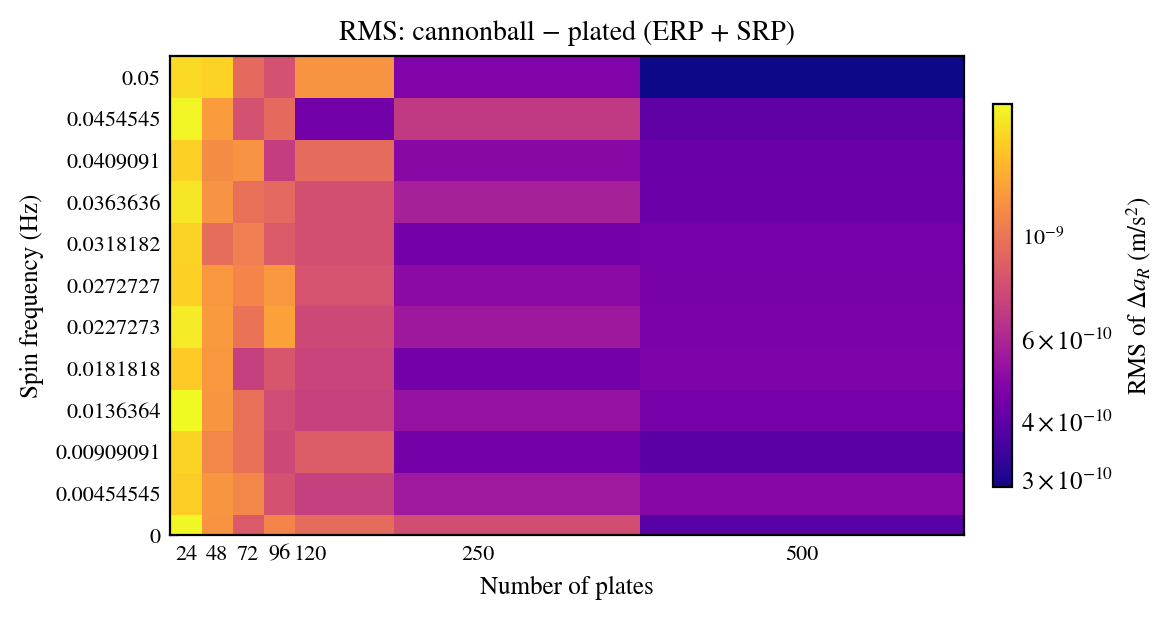

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, SymLogNorm

USE_LOG_SCALES = True  # False: all linear; True: symlog bias / log RMS (curves and colours).

for i, solar_panel_frac in enumerate(solar_panel_fracs):

    all_bias_i = all_bias[:,:,i]
    all_rms_i = all_rms[:,:,i]

# Work on sorted copies, preserving the sweep arrays for subsequent analysis.
    plate_order = np.argsort(n_faces_array)
    frequency_order = np.argsort(spin_f_array)
    plate_counts = np.asarray(n_faces_array)[plate_order]
    spin_frequencies = np.asarray(spin_f_array)[frequency_order]
    expected_shape = (len(spin_f_array), len(n_faces_array))
    if np.shape(all_bias_i) != expected_shape or np.shape(all_rms_i) != expected_shape:
        raise ValueError("Run the sweep first: bias/RMS shapes must match the frequency and plate arrays.")
    bias_by_spin = np.asarray(all_bias_i)[np.ix_(frequency_order, plate_order)]
    rms_by_spin = np.asarray(all_rms_i)[np.ix_(frequency_order, plate_order)]


    def _style_sweep_axes(ax, ylabel):
        ax.set_xlabel('Number of plates', fontsize=Plotter.font_size)
        ax.set_ylabel(ylabel, fontsize=Plotter.font_size)
        ax.set_xticks(plate_counts)
        ax.grid(False)
        ax.tick_params(direction='in', length=3, width=0.8,
                    labelsize=Plotter.font_size_red)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)


    def _sweep_cell_edges(values):
        # Preserve unequal parameter spacing; also support a single sampled value.
        values = np.asarray(values, dtype=float)
        if len(values) == 1:
            half_width = abs(values[0]) / 2 if values[0] else 0.5
            return np.array([max(0, values[0] - half_width), values[0] + half_width])
        midpoints = (values[:-1] + values[1:]) / 2
        return np.r_[max(0, values[0] - (midpoints[0] - values[0])),
                    midpoints, values[-1] + (values[-1] - midpoints[-1])]


    # Keep handles available for saving or adjusting individual figures.
    sweep_figures = {}
    for metric, values in [('Bias', bias_by_spin), ('RMS', rms_by_spin)]:
        # Use the same scale parameters for the curves and the heat map.
        finite_values = values[np.isfinite(values)]
        vmax = np.max(np.abs(finite_values)) if finite_values.size else 0.0
        vmax = vmax if vmax > 0 else np.finfo(float).eps
        plot_values = np.ma.masked_invalid(values)
        if not USE_LOG_SCALES:
            norm = Normalize(vmin=-vmax if metric == 'Bias' else 0, vmax=vmax)
        elif metric == 'Bias':
            # Linear within 1% of the largest absolute bias; logarithmic outside.
            bias_linthresh = max(0.01 * vmax, np.finfo(float).tiny)
            norm = SymLogNorm(linthresh=bias_linthresh, vmin=-vmax, vmax=vmax, base=10)
        else:
            # Zero/nonpositive RMS has no logarithm: leave these entries blank.
            plot_values = np.ma.masked_less_equal(plot_values, 0)
            positive_values = finite_values[finite_values > 0]
            vmin = np.min(positive_values) if positive_values.size else vmax / 10
            if vmin == vmax:
                vmin, vmax = vmin / 10, vmax * 10
            norm = LogNorm(vmin=vmin, vmax=vmax)

        metric_label = rf'{metric} of $\Delta a_R$ (m/s$^2$)'
        fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                        0.8 * Plotter.fig_height), dpi=200)
        for i, spin_f in enumerate(spin_frequencies):
            ax.plot(plate_counts, plot_values[i], label=f'{spin_f:g} Hz',
                    color=Plotter.line_colors[i % len(Plotter.line_colors)],
                    linestyle=Plotter.linestyles[i % len(Plotter.linestyles)],
                    linewidth=Plotter.line_w, marker='o', markersize=3)
        if metric == 'Bias':
            if USE_LOG_SCALES:
                ax.set_yscale('symlog', linthresh=bias_linthresh, base=10)
            ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        elif USE_LOG_SCALES:
            ax.set_yscale('log', base=10)
            ax.set_ylim(vmin, vmax)
        else:
            ax.set_ylim(bottom=0)
        _style_sweep_axes(ax, metric_label)
        ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
        ax.legend(title='Spin frequency', fontsize=Plotter.font_size_red,
                title_fontsize=Plotter.font_size_red, loc='best')
        fig.tight_layout()
        sweep_figures[f'{metric.lower()}_curves'] = (fig, ax)
        plt.show()

        fig, ax = plt.subplots(figsize=(1.5 * Plotter.fig_width,
                                        0.8 * Plotter.fig_height), dpi=200)
        mesh = ax.pcolormesh(_sweep_cell_edges(plate_counts),
                            _sweep_cell_edges(spin_frequencies),
                            plot_values, shading='flat',
                            cmap='seismic' if metric == 'Bias' else 'plasma',
                            norm=norm)
        _style_sweep_axes(ax, 'Spin frequency (Hz)')
        ax.set_yticks(spin_frequencies)
        ax.set_yticklabels([f'{spin_f:g}' for spin_f in spin_frequencies])
        ax.set_title(f'{metric}: cannonball − plated (ERP + SRP)')
        cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, pad=0.03)
        cbar.set_label(metric_label, fontsize=Plotter.font_size)
        cbar.ax.tick_params(labelsize=Plotter.font_size_red)
        fig.tight_layout()
        sweep_figures[f'{metric.lower()}_heatmap'] = (fig, ax)
        plt.show()